In [1]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

I0000 00:00:1785089847.579110    1651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785089848.193889    1651 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785089849.750716    1651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Binary Classification: IMDB Movie Review Sentiment

**Task:** given the text of a movie review, predict whether the sentiment is positive or negative. This is a *binary classification* problem — every example belongs to exactly one of two classes (0 = negative, 1 = positive), and the model's job is to output a single number: the estimated probability that the review is positive.

**Dataset:** the IMDB dataset, built into Keras. It contains 50,000 highly polarized reviews (25,000 for training, 25,000 for testing), split 50/50 between positive and negative. Because the classes are balanced, a model that just guesses would get ~50% accuracy — that's our baseline to beat.

**The overall pipeline we'll build:**
1. Load the reviews as sequences of integer word IDs.
2. Convert each review into a fixed-length numeric vector (since neural networks need fixed-size numeric input, not variable-length lists of words).
3. Build a small feed-forward (densely connected) neural network.
4. Train it while watching a held-out validation set, to see when it starts overfitting.
5. Evaluate and generate predictions on the test set.

`imdb.load_data(num_words=10000)` does two things:

- **Restricts the vocabulary to the 10,000 most frequent words** in the training data. Rare words are dropped. This is a deliberate trade-off: keeping every word would blow up the input dimensionality (tens of thousands of columns) for very little gain, since rare words appear too infrequently to give the model a reliable signal.
- **Pre-tokenizes each review into a list of integers**, where each integer is an index standing in for a specific word (e.g., 3 = "the"). So `train_data[0]` isn't text at all — it's something like `[1, 14, 22, 16, ...]`, a variable-length list of word indices. `train_labels` is the corresponding list of 0/1 sentiment labels.

Note that the reviews have different lengths (one might have 100 words, another 800), which is a problem we'll deal with in the vectorization step below.

In [7]:
# word_index is a dictionary mapping words to an integer index.
word_index = imdb.get_word_index()
# Reverses it, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
# Decodes the review. Note that the indices are offset by 3 because 0,
# 1, and 2 are reserved indices for "padding," "start of sequence," and
# "unknown."
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

This cell just demonstrates how to reverse the encoding back to readable English — it's a sanity check, not something the model needs. The `i - 3` offset exists because Keras reserves indices `0`, `1`, and `2` for "padding," "start of sequence," and "unknown" respectively, so real words are shifted up by 3 in `train_data`.

### Why we need to vectorize at all

Neural networks are built from matrix multiplications: `output = activation(dot(W, input) + b)`. That requires `input` to be a tensor of a *fixed* shape. But `train_data[0]` might have 218 integers and `train_data[1]` might have 189 — you can't stack ragged lists into a matrix. So before any of this can hit a `Dense` layer, every review has to be converted into a vector of the same length. That's what the next cell does.

In [11]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    # Creates an all-zero matrix of shape (len(sequences), num_classes)
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        # Sets specific indices of results[i] to 1s
        results[i][sequence] = 1.0
    return results

# Vectorized training data
x_train = multi_hot_encode(train_data, num_classes=10000)
# Vectorized test data
x_test = multi_hot_encode(test_data, num_classes=10000)

### Multi-hot encoding (a.k.a. "bag of words")

`multi_hot_encode` turns each review — a list of word indices — into a vector of length 10,000 (the vocabulary size). For a given review, the vector is 0 everywhere except at the positions corresponding to words that appear in it, which are set to 1.

- Example: if the vocabulary had only 6 words and a review contained word indices `[3, 5]`, its vector would be `[0, 0, 0, 1, 0, 1]`.
- This is a **set-membership** encoding: it captures *which* words appear, but throws away word order, word count (multiplicity), and grammar entirely. "not good" and "good not" produce the exact same vector.
- Despite being this crude, bag-of-words works surprisingly well for sentiment analysis, because sentiment is often carried by the presence of specific charged words ("terrible," "brilliant") more than by syntax.
- The result, `x_train`, has shape `(25000, 10000)` — 25,000 reviews × a 10,000-dimensional 0/1 vector each. This is now something `Dense` layers can consume.

In [14]:
train_data.shape

(25000,)

In [15]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

Labels are cast to `float32` because Keras loss functions expect floating-point targets to match the model's floating-point predictions (the model outputs a probability like `0.73`, not an integer class).

## Building the network

```python
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
```

This is a **stack of `Dense` (fully connected) layers**, the simplest kind of feed-forward network. Two architectural choices matter here, and both are classic rules of thumb from Chollet's *Deep Learning with Python*:

**1. Why stack layers with `relu` at all (why not just one layer)?**
A single `Dense` layer computes `relu(dot(W, input) + b)` — a linear transformation followed by a simple nonlinearity. Stacking layers lets the network learn richer, hierarchical, non-linear decision boundaries. Without any nonlinearity, stacking `Dense` layers would be pointless — a composition of purely linear functions is still just one linear function, so the extra layers would buy nothing. `relu` (rectified linear unit, `max(0, x)`) is what makes each added layer actually expand what the network can represent, and it's the standard default for hidden layers because it's cheap to compute and avoids some of the training difficulties (vanishing gradients) that older activations like `sigmoid`/`tanh` have in deep stacks.

**2. Why 16 units per layer?**
Each `Dense(16, ...)` layer has 16 "hidden units" — each unit learns a different weighted combination of the input features. 16 is a *representational capacity* knob:
- Too few units (e.g., 4) create an **information bottleneck** — the layer is forced to compress the 10,000-dimensional input into a tiny 4-dimensional space, and may not preserve enough signal to separate positive from negative reviews well.
- Too many units (e.g., 512) give the network more capacity to memorize idiosyncrasies of the *training* set that don't generalize — a direct route to **overfitting**, which is exactly what we'll observe later in this notebook.
- 16 is a reasonable middle ground for a small, dense bag-of-words model like this one — small enough to generalize reasonably, large enough to not obviously starve the model.

**3. Why `sigmoid` on the final layer, and why only 1 unit?**
Since this is *binary* classification, we only need to predict a single quantity: the probability that the review is positive. `sigmoid(x) = 1 / (1 + exp(-x))` squashes any real number into `(0, 1)`, so the output can be directly interpreted as `P(class = 1 | review)`. If this were a multi-class problem (say, 5 possible ratings), we'd instead use `N` output units with a `softmax` activation.

In [ ]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

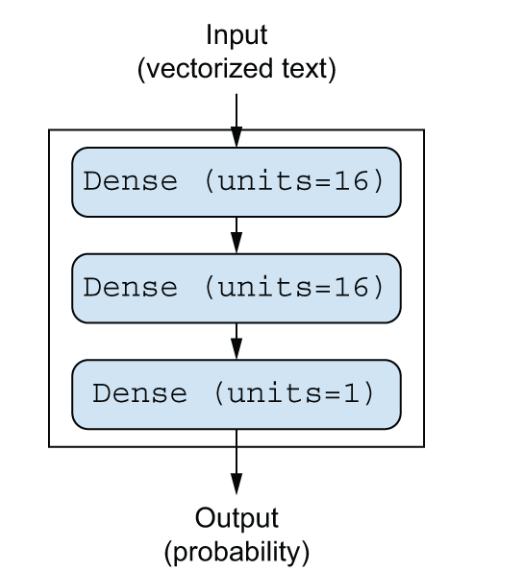

## Compiling: loss, optimizer, metrics

```python
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
```

**Loss function — `binary_crossentropy`:**
Training a network means adjusting its weights to minimize a loss function via gradient descent. For a model outputting probabilities, **binary cross-entropy** (a.k.a. log loss) is the natural choice. For one example with true label `y ∈ {0, 1}` and predicted probability `p = P(y=1)`:

`loss = -(y · log(p) + (1 - y) · log(1 - p))`

Intuitively: if the true label is 1 and the model predicts `p` close to 1, `-log(p)` is close to 0 (small loss). If the model confidently predicts `p` close to 0 for a true label of 1, `-log(p)` blows up toward infinity (huge loss). This asymmetric, heavily-penalize-confident-wrong-answers shape is exactly what you want when training a probabilistic classifier — it's the maximum-likelihood-correct loss for a Bernoulli-distributed target, which pairs mathematically with the `sigmoid` output above (their gradients combine into a very clean, well-behaved form, which is part of why this pairing is the standard one). Using something like mean-squared-error here would work far worse, because its gradient vanishes when the sigmoid saturates near 0 or 1, slowing learning right when the model is most wrong.

**Optimizer — `adam`:**
The optimizer decides *how* to update weights given the gradient of the loss. Plain stochastic gradient descent (SGD) uses a single fixed learning rate for every weight, which can be slow or unstable. **Adam** (Adaptive Moment Estimation) adapts the effective learning rate per-parameter using running estimates of the gradient's mean and variance, which in practice converges faster and needs less manual tuning. It's a reasonable default for most problems, this one included.

**Metric — `accuracy`:**
Loss is what's actually being *optimized*, but it's not very human-readable. `accuracy` (fraction of correctly classified examples) is tracked purely for our own monitoring — it has no effect on training itself.

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

W0000 00:00:1785090740.050350    2048 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1785090740.469779    1651 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Held-out validation data

Training accuracy alone is a misleading signal — a large enough network can eventually memorize the training set and hit ~100% training accuracy while learning nothing generalizable. To detect this, we set aside part of the *training* data (never the test set!) as a **validation set**: 10,000 reviews the model never trains on, whose loss/accuracy we check after every epoch. A gap opening up between training performance and validation performance is the signature of **overfitting**.

In [19]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

## Training: epochs, batch size, and the two `fit()` calls below

`model.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.2)`:

- **Epoch:** one full pass over the training data.
- **Batch size:** the network doesn't compute the gradient over all 25,000 examples at once (too slow, too memory-hungry). Instead it processes `batch_size=512` examples at a time, computes an approximate ("stochastic") gradient from that mini-batch, and takes one weight-update step. One epoch = enough mini-batches to cover the whole training set.
- `validation_split=0.2` here tells Keras to itself carve off the *last* 20% of `x_train`/`y_train` as validation data each epoch — this is a **different, simpler mechanism** than the `x_val`/`partial_x_train` split done manually in the cell above (which isn't actually used by this particular call).

⚠️ **Note on running this notebook top-to-bottom:** the next two cells both call `model.fit(...)` on the *same* `model` object. Keras does not reset weights between `fit()` calls — the second call resumes training from wherever the first one left off. So the "20 epochs" in the second cell are really epochs 21–40 for this model, not a fresh run. That's why, in the recorded output above, the second `fit()` starts from an already very-high (~97-100%) training accuracy: the model was already fit for 20 epochs by the first call. If you want a clean, from-scratch training run using the manual `partial_x_train`/`x_val` split, re-create the model (rerun the cell that builds `model`) immediately before the second `fit()` call, or simply skip running the first `fit()` cell.

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9338 - val_loss: 0.3040
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9336 - val_loss: 0.3098
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9330 - val_loss: 0.3166
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9332 - val_loss: 0.3220
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 9.8683e-04 - val_accuracy: 0.9332 - val_loss: 0.3270
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 9.0846e-04 - val_accuracy: 0.9326 - val_loss: 0.3325
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 8.4435e-04 - val_accuracy: 0.9326 - val_loss: 0.3380
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 7.7456e-04 - val_accuracy: 0

In [30]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9693 - loss: 0.1200 - val_accuracy: 0.9774 - val_loss: 0.0649
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9882 - loss: 0.0363 - val_accuracy: 0.9668 - val_loss: 0.0910
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9987 - loss: 0.0095 - val_accuracy: 0.9659 - val_loss: 0.0918
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9997 - loss: 0.0041 - val_accuracy: 0.9654 - val_loss: 0.1018
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9999 - loss: 0.0025 - val_accuracy: 0.9637 - val_loss: 0.1019
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9643 - val_loss: 0.1054
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 0.9640 - val_loss: 0.1077
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9999 - loss: 8.2366e-04 - val_accuracy: 0.9634 - val_

This second call is the same idea, but passes the manually-carved-out validation set explicitly via `validation_data=(x_val, y_val)`, training only on `partial_x_train`/`partial_y_train` (the remaining 15,000 examples). Functionally equivalent to `validation_split`, just with the split under our own control instead of Keras's default "take the tail end of the array" behavior — useful if you want the split to be, say, shuffled or stratified yourself.

`history` is overwritten here as a `keras.callbacks.History` object, one per `fit()` call, holding the per-epoch loss/accuracy values recorded below.

In [31]:
 history_dict = history.history
 history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Reading the training curves: what overfitting looks like

`history.history` holds four lists, one entry per epoch: training loss/accuracy, and validation loss/accuracy. Plotting them side by side is the standard way to diagnose overfitting.

**What you should expect to see, and why:**
- **Training loss** decreases monotonically — that's the direct result of gradient descent minimizing exactly this quantity, epoch after epoch.
- **Validation loss** decreases at first (the model is learning genuinely useful patterns), but then **turns around and starts increasing**, even though training loss keeps falling. That crossover point is the model transitioning from *learning general patterns about sentiment* to *memorizing specifics of the training examples* (down to noise that doesn't hold on unseen data) — the very definition of overfitting.
- The epoch where validation loss is at its minimum is, in principle, the best stopping point — training past it doesn't help real-world performance even though the training metrics keep looking better and better. (In a production setup you'd typically use `EarlyStopping` or just retrain for that many epochs, rather than eyeballing a chart after the fact.)

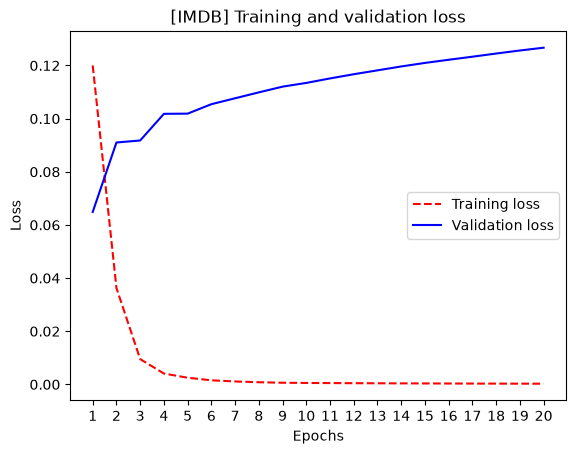

In [32]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
# "r--" is for "dashed red line."
plt.plot(epochs, loss_values, "r--", label="Training loss")
# "b" is for "solid blue line."
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

Same story, mirrored: **training accuracy** climbs toward 100% (the model increasingly nails the exact training examples), while **validation accuracy** plateaus and can even wobble downward once overfitting sets in, since accuracy is a noisier, less smooth signal than loss.

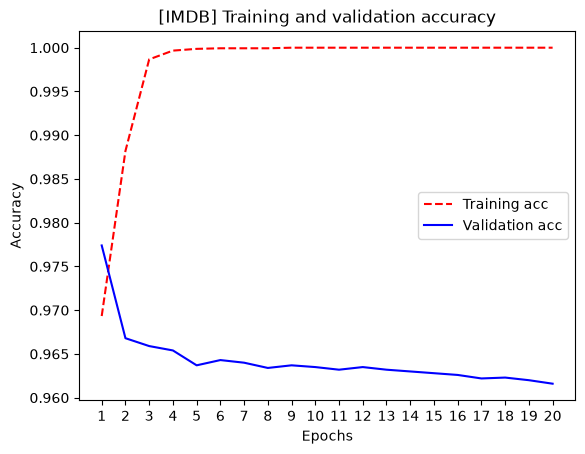

In [33]:
# Clears the figure
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [34]:
 model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ -0s -634us/step


array([[1.9329130e-04],
       [1.0000000e+00],
       [9.9998957e-01],
       ...,
       [9.6606826e-03],
       [8.2483451e-04],
       [9.9999022e-01]], shape=(25000, 1), dtype=float32)

## What `predict` returns, and where to go from here

`model.predict(x_test)` runs the trained network forward on unseen reviews and returns, for each one, the `sigmoid` output — a probability in `(0, 1)`. A value like `0.9999` means "very confidently positive"; `0.0002` means "very confidently negative." To get a hard 0/1 class label you'd threshold at 0.5 (`(predictions > 0.5).astype(int)`), though the raw probability is often more useful (e.g., for ranking reviews by confidence, or adjusting the threshold based on the cost of false positives vs. false negatives).

**Takeaways from this notebook, and natural next steps:**
- The overfitting observed above is a direct consequence of network capacity vs. data + training length. Standard remedies: stop training earlier (`EarlyStopping`), add `Dropout` layers, add L1/L2 weight regularization, or reduce the number of units/layers.
- Bag-of-words vectorization discards word order. A recurrent, convolutional, or Transformer-based model working on the original *sequence* of word indices (rather than a multi-hot vector) can pick up on phrase-level and word-order effects — e.g., distinguishing "not good" from "good" — that this model structurally cannot.